In [21]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from typing import Optional, List

# Para que los gráficos salgan dentro del notebook
%matplotlib inline

BASE_DIR = Path.cwd()
DATA_PATH = BASE_DIR / "Data" / "quirofano_2025_limpio.csv"

print("Base:", BASE_DIR)
print("CSV encontrado:", DATA_PATH.exists())
print("Ruta CSV:", DATA_PATH)

Base: c:\Users\dario\Desktop\UNIVERSIDAD\Ingenieria de la salud- UBU\HUBU\Proyecto_PR
CSV encontrado: True
Ruta CSV: c:\Users\dario\Desktop\UNIVERSIDAD\Ingenieria de la salud- UBU\HUBU\Proyecto_PR\Data\quirofano_2025_limpio.csv


In [22]:
df = pd.read_csv(DATA_PATH, parse_dates=["fecha", "inicio_dt", "fin_dt"])
df.head()

,paciente_id,servicio,quirofano,centro,fecha,hora_inicio,hora_fin,anestesia,ambulatorio,tipo_caso,...,suspendida,motivo_suspension,provincia,sector,inicio_dt,fin_dt,duracion_min,duracion_horas,es_urgencia,esta_suspendida
0,593387,CGD,QE1,NaN,2025-01-02,19:55,20:40,LOCAL MAS SEDACION,S,U,...,N,NaN,BURGOS,9-Desconocido,2025-01-02 19:55:00,2025-01-02 20:40:00,45.0,0.750000,True,False
1,318635,CGD,QE5,NaN,2025-01-02,11:10,13:00,GENERAL,N,U,...,N,NaN,BURGOS,9-Desconocido,2025-01-02 11:10:00,2025-01-02 13:00:00,110.0,1.833333,True,False
2,494371,CGD,QE6,NaN,2025-01-02,08:40,10:10,GENERAL,N,P,...,N,NaN,BURGOS,9-Desconocido,2025-01-02 08:40:00,2025-01-02 10:10:00,90.0,1.500000,False,False
3,448548,CGD,QE6,NaN,2025-01-02,10:25,14:05,GENERAL,N,P,...,N,NaN,BURGOS,9-Desconocido,2025-01-02 10:25:00,2025-01-02 14:05:00,220.0,3.666667,False,False
4,125848,CGD,QE8,NaN,2025-01-02,08:30,11:58,GENERAL,N,P,...,N,NaN,BURGOS,9-Desconocido,2025-01-02 08:30:00,2025-01-02 11:58:00,208.0,3.466667,False,False


In [23]:
df_real = df[df["esta_suspendida"] == False].copy()

print("Total registros:", len(df))
print("Cirugías reales:", len(df_real))
print("Urgencias reales:", int(df_real["es_urgencia"].sum()))
print("Quirófanos utilizados:", df_real["quirofano"].nunique())

Total registros: 3455
Cirugías reales: 3451
Urgencias reales: 779
Quirófanos utilizados: 8


In [24]:
resumen = pd.DataFrame([{
    "cirugías_reales": len(df_real),
    "urgencias": int(df_real["es_urgencia"].sum()),
    "quirofanos_utilizados": int(df_real["quirofano"].nunique()),
    "duracion_media_min": round(df_real["duracion_min"].mean(), 2),
    "duracion_mediana_min": round(df_real["duracion_min"].median(), 2),
}])

resumen

,cirugías_reales,urgencias,quirofanos_utilizados,duracion_media_min,duracion_mediana_min
0,3451,779,8,96.01,70.0


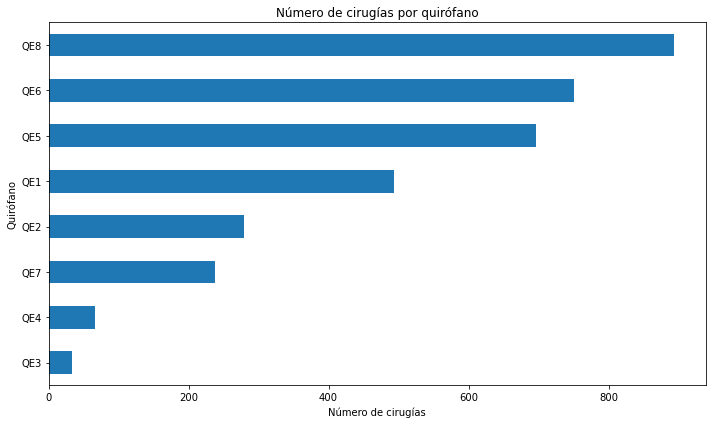

In [25]:
uso_qx = df_real["quirofano"].value_counts().sort_values(ascending=True)

plt.figure(figsize=(10, 6))
uso_qx.plot(kind="barh")
plt.title("Número de cirugías por quirófano")
plt.xlabel("Número de cirugías")
plt.ylabel("Quirófano")
plt.tight_layout()
plt.show()

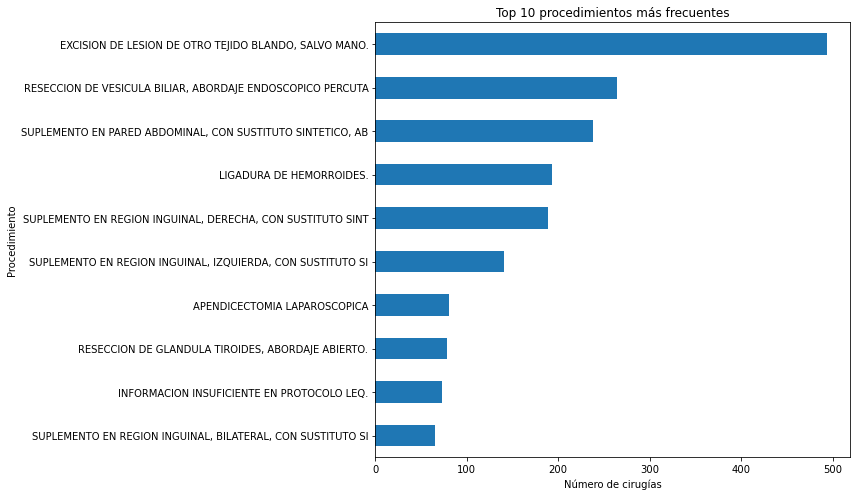

In [26]:
top_proc = (
    df_real["procedimiento"]
    .value_counts()
    .head(10)
    .sort_values(ascending=True)
)

plt.figure(figsize=(12, 7))
top_proc.plot(kind="barh")
plt.title("Top 10 procedimientos más frecuentes")
plt.xlabel("Número de cirugías")
plt.ylabel("Procedimiento")
plt.tight_layout()
plt.show()

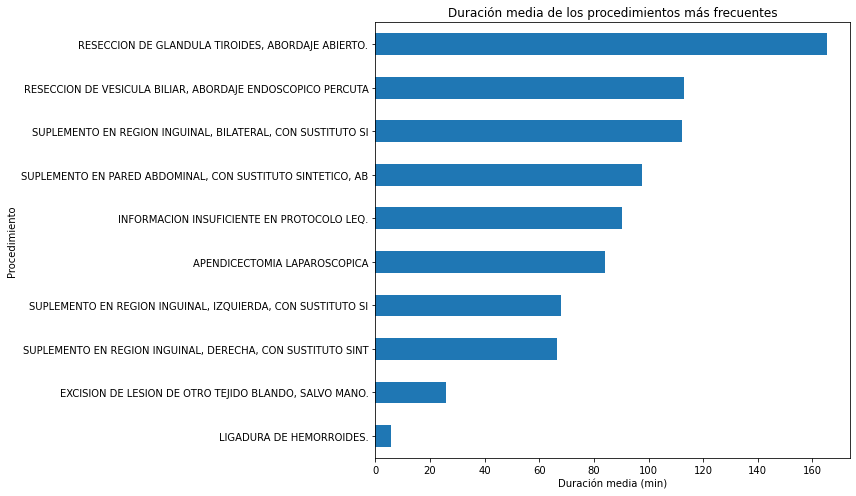

In [27]:
dur_proc = (
    df_real[df_real["procedimiento"].isin(top_proc.index)]
    .groupby("procedimiento")["duracion_min"]
    .mean()
    .sort_values(ascending=True)
)

plt.figure(figsize=(12, 7))
dur_proc.plot(kind="barh")
plt.title("Duración media de los procedimientos más frecuentes")
plt.xlabel("Duración media (min)")
plt.ylabel("Procedimiento")
plt.tight_layout()
plt.show()

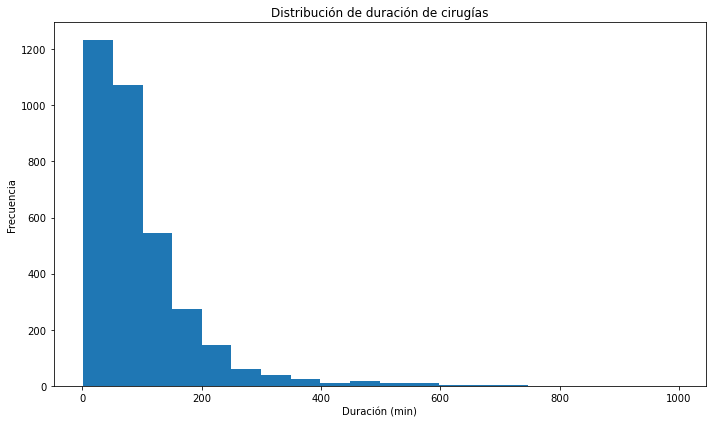

In [28]:
plt.figure(figsize=(10, 6))
plt.hist(df_real["duracion_min"].dropna(), bins=20)
plt.title("Distribución de duración de cirugías")
plt.xlabel("Duración (min)")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

In [29]:
df_gap = df_real.sort_values(["quirofano", "fecha", "inicio_dt"]).copy()

df_gap["fin_anterior"] = df_gap.groupby(["quirofano", "fecha"])["fin_dt"].shift(1)
df_gap["tiempo_muerto_min"] = (
    df_gap["inicio_dt"] - df_gap["fin_anterior"]
).dt.total_seconds() / 60

tiempo_medio = df_gap["tiempo_muerto_min"].dropna().mean()
print("Tiempo muerto medio real entre cirugías (mismo día):", round(tiempo_medio, 2), "min")

Tiempo muerto medio real entre cirugías (mismo día): 57.29 min


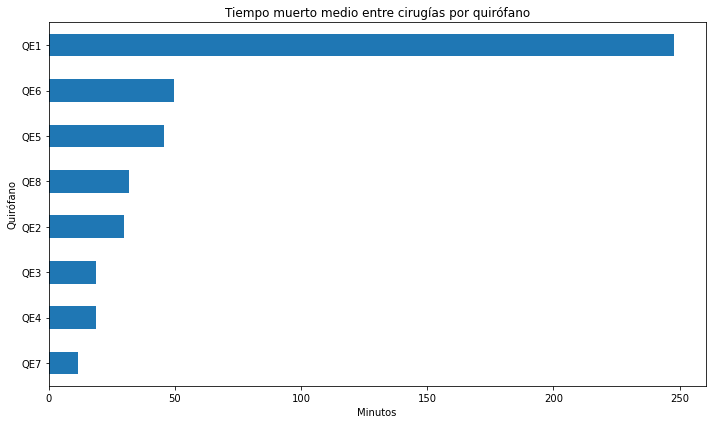

In [30]:
gap_por_qx = (
    df_gap.groupby("quirofano")["tiempo_muerto_min"]
    .mean()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))
gap_por_qx.plot(kind="barh")
plt.title("Tiempo muerto medio entre cirugías por quirófano")
plt.xlabel("Minutos")
plt.ylabel("Quirófano")
plt.tight_layout()
plt.show()

In [31]:
tabla_proc = (
    df_real.groupby("procedimiento")
    .agg(
        n_cirugias=("procedimiento", "count"),
        duracion_media=("duracion_min", "mean"),
        duracion_mediana=("duracion_min", "median"),
        desviacion=("duracion_min", "std")
    )
    .sort_values("n_cirugias", ascending=False)
    .head(15)
    .round(2)
)



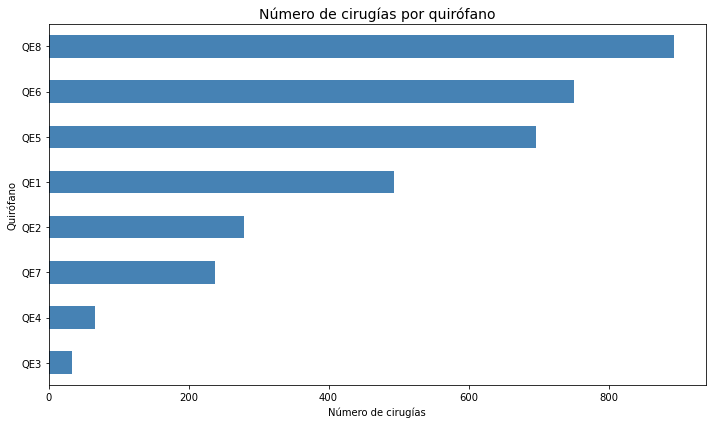

In [32]:
plt.figure(figsize=(10, 6))
uso_qx.plot(kind="barh", color="steelblue")
plt.title("Número de cirugías por quirófano", fontsize=14)
plt.xlabel("Número de cirugías")
plt.ylabel("Quirófano")
plt.tight_layout()
plt.show()

In [42]:
from Proyecto.analisis_quirofano import (
    cargar_datos,
    preparar_dataset_funcional,
    construir_catalogo_quirurgico,
    estimar_nueva_cirugia
)

In [43]:
df = cargar_datos()
df_funcional = preparar_dataset_funcional(df)
catalogo = construir_catalogo_quirurgico(df_funcional)

catalogo.head(10)

,procedimiento_base,n_casos,duracion_media_min,duracion_mediana_min,desviacion_min,quirofanos_habituales,prep_min,post_min,buffer_variabilidad_min,duracion_planificable_min
0,"EXCISION DE LESION DE OTRO TEJIDO BLANDO, SALV...",494,25.69,23.5,13.67,"QE2, QE5, QE6, QE7, QE8",15,10,7.0,56.0
1,COLECISTECTOMIA LAPAROSCOPICA,289,114.49,100.0,46.59,"QE1, QE2, QE3, QE4, QE5, QE6, QE7, QE8",15,10,23.0,148.0
2,"SUPLEMENTO EN PARED ABDOMINAL, CON SUSTITUTO S...",238,97.67,65.0,75.54,"QE1, QE2, QE3, QE4, QE5, QE6, QE7, QE8",15,10,38.0,128.0
3,LIGADURA DE HEMORROIDES.,193,5.53,5.0,1.78,"QE2, QE5, QE6, QE7, QE8",15,10,1.0,31.0
4,HERNIA INGUINAL DERECHA,189,66.47,65.0,21.94,"QE2, QE3, QE4, QE5, QE6, QE7, QE8",15,10,11.0,101.0
5,HERNIA INGUINAL IZQUIERDA,141,68.01,65.0,21.53,"QE2, QE3, QE4, QE5, QE6, QE7, QE8",15,10,11.0,101.0
6,APENDICECTOMIA LAPAROSCOPICA,117,85.67,80.0,23.69,"QE1, QE2, QE4, QE5, QE6, QE7, QE8",15,10,12.0,117.0
7,"RESECCION DE GLANDULA TIROIDES, ABORDAJE ABIERTO.",78,165.33,145.0,65.61,"QE1, QE2, QE4, QE5, QE6, QE7, QE8",15,10,33.0,203.0
8,INFORMACION INSUFICIENTE EN PROTOCOLO LEQ.,73,90.19,65.0,88.54,"QE2, QE3, QE4, QE5, QE6, QE7, QE8",15,10,44.0,134.0
9,"SUPLEMENTO EN REGION INGUINAL, BILATERAL, CON ...",65,112.29,105.0,42.83,"QE2, QE3, QE4, QE5, QE6, QE7, QE8",15,10,21.0,151.0


In [44]:
estimacion = estimar_nueva_cirugia(catalogo, "APENDICECTOMIA LAPAROSCOPICA")
estimacion

{'procedimiento': 'APENDICECTOMIA LAPAROSCOPICA',
 'n_casos_historicos': 117,
 'duracion_mediana_min': 80.0,
 'prep_min': 15.0,
 'post_min': 10.0,
 'buffer_variabilidad_min': 12.0,
 'duracion_planificable_min': 117.0,
 'quirofanos_habituales': 'QE1, QE2, QE4, QE5, QE6, QE7, QE8'}

In [45]:
import pandas as pd

pd.DataFrame([estimacion]).T.rename(columns={0: "valor"})

,valor
procedimiento,APENDICECTOMIA LAPAROSCOPICA
n_casos_historicos,117
duracion_mediana_min,80.0
prep_min,15.0
post_min,10.0
buffer_variabilidad_min,12.0
duracion_planificable_min,117.0
quirofanos_habituales,"QE1, QE2, QE4, QE5, QE6, QE7, QE8"


In [46]:
procedimientos_prueba = [
    "APENDICECTOMIA LAPAROSCOPICA",
    "COLECISTECTOMIA LAPAROSCOPICA",
    "HERNIA INGUINAL DERECHA"
]

resultados = [estimar_nueva_cirugia(catalogo, p) for p in procedimientos_prueba]
pd.DataFrame(resultados)

,procedimiento,n_casos_historicos,duracion_mediana_min,prep_min,post_min,buffer_variabilidad_min,duracion_planificable_min,quirofanos_habituales
0,APENDICECTOMIA LAPAROSCOPICA,117,80.0,15.0,10.0,12.0,117.0,"QE1, QE2, QE4, QE5, QE6, QE7, QE8"
1,COLECISTECTOMIA LAPAROSCOPICA,289,100.0,15.0,10.0,23.0,148.0,"QE1, QE2, QE3, QE4, QE5, QE6, QE7, QE8"
2,HERNIA INGUINAL DERECHA,189,65.0,15.0,10.0,11.0,101.0,"QE2, QE3, QE4, QE5, QE6, QE7, QE8"


In [52]:
from Proyecto.analisis_quirofano import (
    cargar_datos,
    preparar_dataset_funcional,
    construir_catalogo_quirurgico,
    proponer_huecos
)

df = cargar_datos()
df_real = preparar_dataset_funcional(df)

catalogo = construir_catalogo_quirurgico(df_real)

proponer_huecos(
    df_real,
    catalogo,
    "APENDICECTOMIA LAPAROSCOPICA",
    "2026-02-02"
)

,procedimiento,quirofano,inicio,fin_estimado,duracion_necesaria,duracion_disponible,holgura_min,es_quirofano_habitual
0,APENDICECTOMIA LAPAROSCOPICA,QE1,2026-02-02 08:00:00,2026-02-02 09:57:00,117.0,720.0,603.0,True
1,APENDICECTOMIA LAPAROSCOPICA,QE2,2026-02-02 08:00:00,2026-02-02 09:57:00,117.0,720.0,603.0,True
2,APENDICECTOMIA LAPAROSCOPICA,QE4,2026-02-02 08:00:00,2026-02-02 09:57:00,117.0,720.0,603.0,True
3,APENDICECTOMIA LAPAROSCOPICA,QE5,2026-02-02 08:00:00,2026-02-02 09:57:00,117.0,720.0,603.0,True
4,APENDICECTOMIA LAPAROSCOPICA,QE6,2026-02-02 08:00:00,2026-02-02 09:57:00,117.0,720.0,603.0,True


In [51]:
from Proyecto.analisis_quirofano import (
    cargar_datos,
    preparar_dataset_funcional,
    construir_catalogo_quirurgico,
    proponer_huecos
)

df = cargar_datos()
df_real = preparar_dataset_funcional(df)
catalogo = construir_catalogo_quirurgico(df_real)

proponer_huecos(
    df_real=df_real,
    catalogo=catalogo,
    procedimiento="APENDICECTOMIA LAPAROSCOPICA",
    fecha="2026-02-02",
    hora_inicio_bloque="08:00",
    hora_fin_bloque="20:00",
    quirofanos_validos=["QE1", "QE2", "QE5", "QE6", "QE7", "QE8"]
)

,procedimiento,quirofano,inicio,fin_estimado,duracion_necesaria,duracion_disponible,holgura_min,es_quirofano_habitual
0,APENDICECTOMIA LAPAROSCOPICA,QE1,2026-02-02 08:00:00,2026-02-02 09:57:00,117.0,720.0,603.0,True
1,APENDICECTOMIA LAPAROSCOPICA,QE2,2026-02-02 08:00:00,2026-02-02 09:57:00,117.0,720.0,603.0,True
2,APENDICECTOMIA LAPAROSCOPICA,QE5,2026-02-02 08:00:00,2026-02-02 09:57:00,117.0,720.0,603.0,True
3,APENDICECTOMIA LAPAROSCOPICA,QE6,2026-02-02 08:00:00,2026-02-02 09:57:00,117.0,720.0,603.0,True
4,APENDICECTOMIA LAPAROSCOPICA,QE7,2026-02-02 08:00:00,2026-02-02 09:57:00,117.0,720.0,603.0,True


In [40]:
from Proyecto.analisis_quirofano import (
    cargar_datos,
    preparar_dataset_funcional,
    construir_catalogo_quirurgico,
    proponer_huecos
)

df = cargar_datos()
df_real = preparar_dataset_funcional(df)
catalogo = construir_catalogo_quirurgico(df_real)

candidatos = proponer_huecos(
    df_real=df_real,
    catalogo=catalogo,
    procedimiento="APENDICECTOMIA LAPAROSCOPICA",
    fecha="2026-02-02",
    hora_inicio_bloque="08:00",
    hora_fin_bloque="20:00",
    quirofanos_validos=["QE1", "QE2", "QE5", "QE6", "QE7", "QE8"],
    max_resultados=5
)

candidatos

,procedimiento,quirofano,inicio,fin_estimado,duracion_necesaria,duracion_disponible,holgura_min,es_quirofano_habitual
0,APENDICECTOMIA LAPAROSCOPICA,QE1,2026-02-02 08:00:00,2026-02-02 09:57:00,117.0,720.0,603.0,True
1,APENDICECTOMIA LAPAROSCOPICA,QE2,2026-02-02 08:00:00,2026-02-02 09:57:00,117.0,720.0,603.0,True
2,APENDICECTOMIA LAPAROSCOPICA,QE5,2026-02-02 08:00:00,2026-02-02 09:57:00,117.0,720.0,603.0,True
3,APENDICECTOMIA LAPAROSCOPICA,QE6,2026-02-02 08:00:00,2026-02-02 09:57:00,117.0,720.0,603.0,True
4,APENDICECTOMIA LAPAROSCOPICA,QE7,2026-02-02 08:00:00,2026-02-02 09:57:00,117.0,720.0,603.0,True
